In [1]:
# ----- config -----
from pathlib import Path
import numpy as np, SimpleITK as sitk, pandas as pd, re
from scipy.ndimage import binary_dilation, label as cc_label

FOLD_DIR = {
    0: Path(r"E:\nnUNet_results\predictions_fold0_unlab"),
    1: Path(r"E:\nnUNet_results\predictions_fold1_unlab"),
    2: Path(r"E:\nnUNet_results\predictions_fold2_unlab"),
}
OUT_MULTI = Path(r"E:\nnUNet_raw\Dataset110_PANTHER_T1\LabelsPseudo_multiclass")
OUT_MULTI.mkdir(parents=True, exist_ok=True)

DILATE_MM = 10.0     # pancreas dilation (mm) for tumor gate
MIN_FR    = 0.15     # min tumor fraction inside dilated pancreas
MIN_VOX   = 10       # min tumor component size (voxels)

# ----- helpers -----
def niigz_stem(p: Path) -> str:
    return p.name[:-7] if p.name.endswith(".nii.gz") else p.stem

def index_dir(d: Path) -> dict:
    return {niigz_stem(p): p for p in d.glob("*.nii.gz")}

idx = {k: index_dir(v) for k,v in FOLD_DIR.items()}
stems = sorted(set(idx[0]).intersection(idx[1]).intersection(idx[2]))

def mv_labels(a0, a1, a2):
    A = np.stack([a0, a1, a2], 0)
    counts = np.stack([(A==c).sum(0) for c in (0,1,2)], 0)
    return counts.argmax(0).astype(np.uint8)

def clean_pancreas(pan):
    if pan.sum()==0: return pan.astype(np.uint8)
    lab, n = cc_label(pan.astype(np.uint8))
    sizes = np.bincount(lab.ravel()); sizes[0]=0
    keep = (lab == sizes.argmax()).astype(np.uint8)   # largest component
    return keep

def anisotropic_ball_radii(spacing_xyz, dil_mm):
    sx, sy, sz = spacing_xyz  # (x,y,z), arrays are (z,y,x)
    rx = max(1, int(round(dil_mm/sx)))
    ry = max(1, int(round(dil_mm/sy)))
    rz = max(1, int(round(dil_mm/sz)))
    return rz, ry, rx

def gate_tumor(tum, pan, spacing_xyz, min_vox=MIN_VOX, min_fr=MIN_FR, dil_mm=DILATE_MM):
    rz, ry, rx = anisotropic_ball_radii(spacing_xyz, dil_mm)
    zz,yy,xx = np.ogrid[-rz:rz+1, -ry:ry+1, -rx:rx+1]
    se = (zz*zz/(rz*rz+1e-6)+yy*yy/(ry*ry+1e-6)+xx*xx/(rx*rx+1e-6))<=1
    pan_d = binary_dilation(pan.astype(bool), structure=se)

    lab, n = cc_label(tum.astype(np.uint8))
    out = np.zeros_like(tum, dtype=np.uint8)
    for k in range(1, n+1):
        comp = (lab==k)
        sz   = int(comp.sum())
        if sz < min_vox: continue
        frac = (comp & pan_d).sum() / (sz + 1e-8)
        if frac >= min_fr:
            out |= comp
    return out.astype(np.uint8)

# ----- build multiclass masks -----
rows = []
for s in stems:
    im0 = sitk.ReadImage(str(idx[0][s])); a0 = sitk.GetArrayFromImage(im0)
    a1 = sitk.GetArrayFromImage(sitk.ReadImage(str(idx[1][s])))
    a2 = sitk.GetArrayFromImage(sitk.ReadImage(str(idx[2][s])))

    mv = mv_labels(a0, a1, a2)
    pan_mv = clean_pancreas((mv==2).astype(np.uint8))
    tum_mv = (mv==1).astype(np.uint8)

    # gate tumor by dilated pancreas
    spacing_xyz = im0.GetSpacing()  # (x,y,z)
    tum_keep = gate_tumor(tum_mv, pan_mv, spacing_xyz)

    # compose multiclass: 0 bg, 1 tumor, 2 pancreas (tumor overrides pancreas)
    out = np.zeros_like(mv, dtype=np.uint8)
    out[pan_mv==1] = 2
    out[tum_keep==1] = 1

    out_im = sitk.GetImageFromArray(out); out_im.CopyInformation(im0)
    out_name = re.sub(r"_0\d{3}$", "", s) + ".nii.gz"  # drop _0000 in filename
    sitk.WriteImage(out_im, str(OUT_MULTI/out_name))

    rows.append({"case": out_name,
                 "tumor_vox": int((out==1).sum()),
                 "pancreas_vox": int((out==2).sum())})

qc = pd.DataFrame(rows)
qc.to_csv(OUT_MULTI/"multiclass_qc.csv", index=False)
print(f"Saved {len(rows)} multiclass pseudo labels -> {OUT_MULTI}")
print(qc.head())


Saved 367 multiclass pseudo labels -> E:\nnUNet_raw\Dataset110_PANTHER_T1\LabelsPseudo_multiclass
                case  tumor_vox  pancreas_vox
0  10000_0002.nii.gz          0            92
1  10000_0003.nii.gz       1352         15005
2  10000_0004.nii.gz       4094          2194
3  10001_0002.nii.gz       4649          8715
4  10001_0003.nii.gz          0          4547


In [2]:
from pathlib import Path
import pandas as pd

OUT_MULTI = Path(r"E:\nnUNet_raw\Dataset110_PANTHER_T1\LabelsPseudo_multiclass")
qc_csv = OUT_MULTI / "multiclass_qc.csv"

qc = pd.read_csv(qc_csv)
qc["stem"] = qc["case"].str.replace(".nii.gz", "", regex=False)

total = len(qc)
tum_pos = int((qc["tumor_vox"] > 0).sum())
tum_neg = total - tum_pos
pan_pos = int((qc["pancreas_vox"] > 0).sum())
empty  = int(((qc["tumor_vox"]==0) & (qc["pancreas_vox"]==0)).sum())

print(f"Total: {total}")
print(f"Tumor-positive: {tum_pos}  ({tum_pos/total:.1%})")
print(f"Tumor-negative: {tum_neg}  ({tum_neg/total:.1%})")
print(f"Pancreas present: {pan_pos}  ({pan_pos/total:.1%})")
print(f"Empty (no tumor & no pancreas): {empty}")

pos_stems = qc.loc[qc["tumor_vox"]>0, "stem"].tolist()
neg_stems = qc.loc[qc["tumor_vox"]==0, "stem"].tolist()
print("\nSample tumor+:", pos_stems[:5])
print("Sample tumor-:", neg_stems[:5])


Total: 367
Tumor-positive: 192  (52.3%)
Tumor-negative: 175  (47.7%)
Pancreas present: 329  (89.6%)
Empty (no tumor & no pancreas): 38

Sample tumor+: ['10000_0003', '10000_0004', '10001_0002', '10001_0005', '10006_0002']
Sample tumor-: ['10000_0002', '10001_0003', '10001_0004', '10002_0002', '10007_0002']


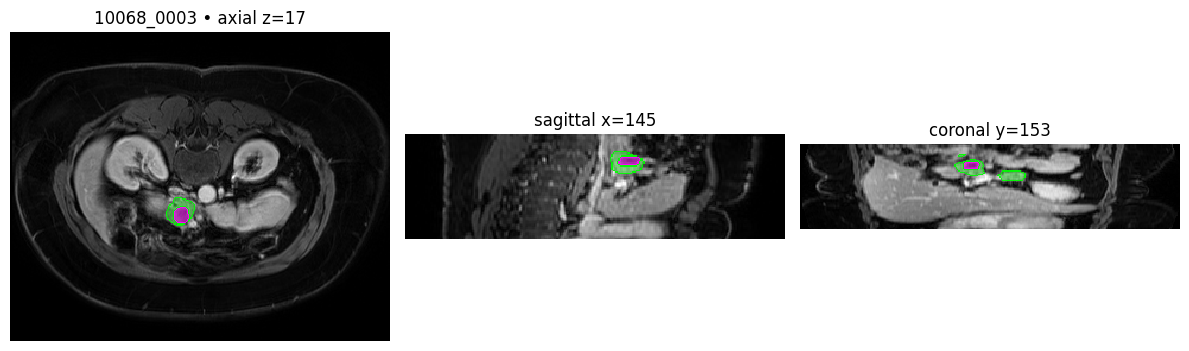

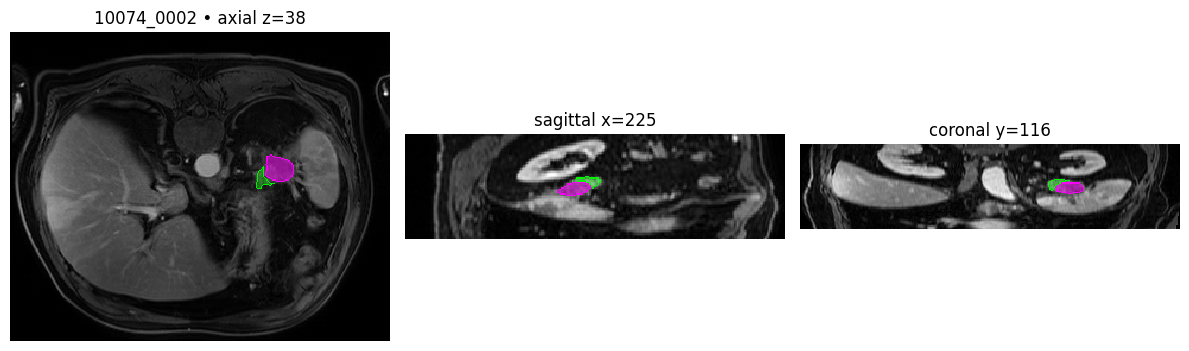

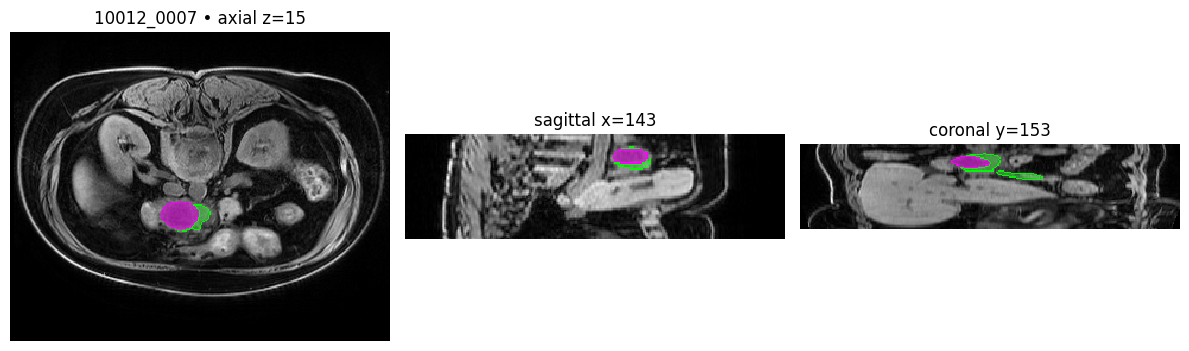

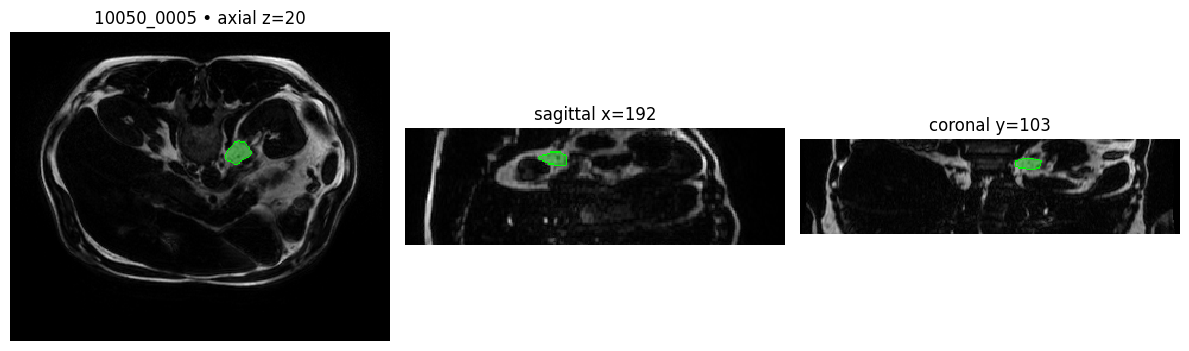

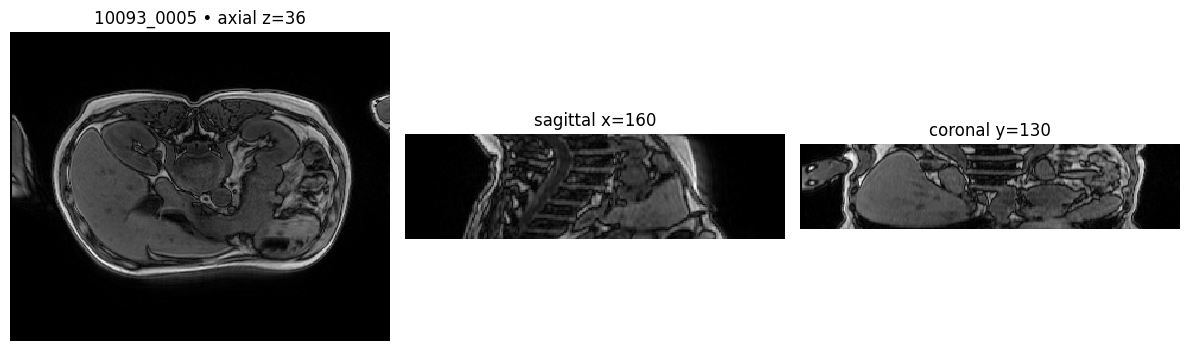

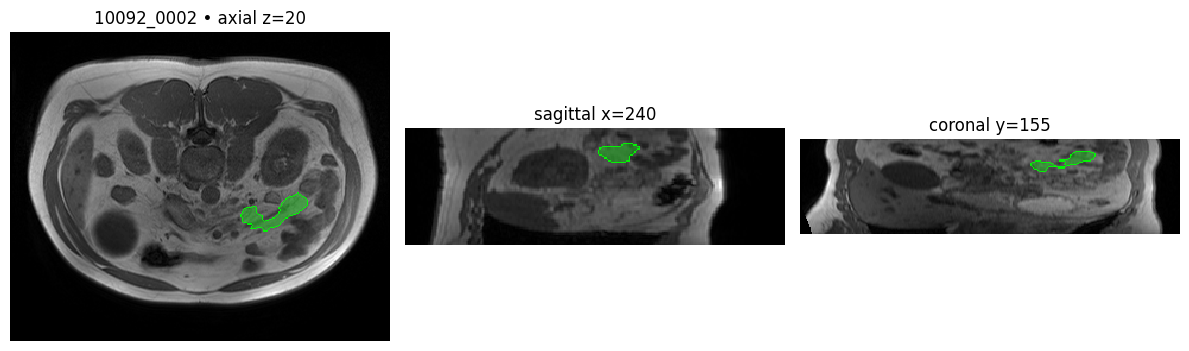

In [4]:
import re, random, numpy as np, matplotlib.pyplot as plt, SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_erosion

OUT_MULTI  = Path(r"E:\nnUNet_raw\Dataset110_PANTHER_T1\LabelsPseudo_multiclass")
UNLAB_NII  = Path(r"E:\499\Data\task 1\ImagesTr_unlabeled_nii")

def image_path_for_stem(stem: str) -> Path | None:
    cands = [
        UNLAB_NII / f"{stem}.nii.gz",
        UNLAB_NII / f"{stem}_0000.nii.gz",
        UNLAB_NII / (re.sub(r"_0\d{3}$", "", stem) + "_0000.nii.gz"),
    ]
    for c in cands:
        if c.exists(): return c
    return None

def load_arr(p: Path):
    im = sitk.ReadImage(str(p)); return sitk.GetArrayFromImage(im), im

def pick_slices(tum, pan):
    focus = tum if tum.sum() > 0 else pan
    if focus.sum() == 0:
        return focus.shape[0]//2, focus.shape[2]//2, focus.shape[1]//2
    z = int(np.argmax(focus.reshape(focus.shape[0], -1).sum(1)))
    x = int(np.argmax(focus.transpose(2,0,1).reshape(focus.shape[2], -1).sum(1)))
    y = int(np.argmax(focus.transpose(1,0,2).reshape(focus.shape[1], -1).sum(1)))
    return z, x, y

def rgb_overlay(mask2d, color, alpha):
    """Return an RGBA image for a binary mask."""
    h, w = mask2d.shape
    rgba = np.zeros((h, w, 4), dtype=float)
    rgba[mask2d.astype(bool), :3] = color
    rgba[mask2d.astype(bool),  3] = alpha
    return rgba

def show_case(stem: str, draw_outlines=True):
    img_p = image_path_for_stem(stem)
    lbl_p = OUT_MULTI / f"{stem}.nii.gz"
    if img_p is None:
        print("Image missing for", stem); return
    if not lbl_p.exists():
        print("Label missing for", stem); return

    img, _ = load_arr(img_p)           # (z,y,x)
    lab, _ = load_arr(lbl_p)           # 0 bg, 1 tumor, 2 pancreas
    tum = (lab == 1).astype(np.uint8)
    pan = (lab == 2).astype(np.uint8)

    z,x,y = pick_slices(tum, pan)

    def panel(im2d, t2d, p2d, title):
        plt.imshow(im2d, cmap='gray', interpolation='none')
        # filled overlays
        plt.imshow(rgb_overlay(p2d, color=(0.0, 0.9, 0.0), alpha=0.35), interpolation='none')  # green
        plt.imshow(rgb_overlay(t2d, color=(0.9, 0.0, 0.9), alpha=0.55), interpolation='none')  # magenta
        # thin outlines (optional)
        if draw_outlines:
            t_edge = (t2d.astype(bool) ^ binary_erosion(t2d.astype(bool)))
            p_edge = (p2d.astype(bool) ^ binary_erosion(p2d.astype(bool)))
            plt.imshow(rgb_overlay(p_edge, color=(0.0, 1.0, 0.0), alpha=0.9), interpolation='none')
            plt.imshow(rgb_overlay(t_edge, color=(1.0, 0.0, 1.0), alpha=0.9), interpolation='none')
        plt.title(title); plt.axis('off')

    plt.figure(figsize=(12,4))
    panel_list = [
        (img[z],     tum[z],     pan[z],     f"{stem} • axial z={z}"),
        (img[:,:,x], tum[:,:,x], pan[:,:,x], f"sagittal x={x}"),
        (img[:,y,:], tum[:,y,:], pan[:,y,:], f"coronal y={y}"),
    ]
    for i,(im2d,t2d,p2d,title) in enumerate(panel_list,1):
        plt.subplot(1,3,i); panel(im2d,t2d,p2d,title)
    plt.tight_layout(); plt.show()

# demo on a few positives and negatives
import pandas as pd
qc = pd.read_csv(OUT_MULTI/"multiclass_qc.csv")
qc["stem"] = qc["case"].str.replace(".nii.gz","",regex=False)
pos = qc.loc[qc.tumor_vox>0,"stem"].tolist()
neg = qc.loc[qc.tumor_vox==0,"stem"].tolist()

import random
random.seed(0)
for s in random.sample(pos, k=min(3,len(pos))): show_case(s)
for s in random.sample(neg, k=min(3,len(neg))): show_case(s)
